<a href="https://colab.research.google.com/github/mfachriridwan/claude/blob/main/fix_no_error_riset_LCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install osmnx folium deap openpyxl -q

import osmnx as ox, networkx as nx, numpy as np, pandas as pd, random, requests, time, os
from shapely.geometry import Point, box
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde, mannwhitneyu
from scipy.interpolate import RegularGridInterpolator
from sklearn.cluster import KMeans
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MPath
import zipfile, shutil

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

# ── KONSTANTA ────────────────────────────────────────────────────────────────
PLACE = "Payakumbuh, West Sumatra, Indonesia"
TPA   = (-0.264939, 100.631044)
KEC   = {"Payakumbuh Barat":12, "Payakumbuh Utara":8, "Payakumbuh Timur":7,
         "Lamposi Tigo Nagari":4, "Payakumbuh Selatan":4}
N_TRUCK, CAP, SPEED, T_LOAD, T_UNLOAD = 8, 500, 30, 7, 20
P, N_RUNS, N_SAMPLE = 35, 200, 400

# ── Download OSM ─────────────────────────────────────────────────────────────
print("Download OSM...")
G    = ox.add_edge_travel_times(ox.add_edge_speeds(ox.graph_from_place(PLACE, network_type="drive")))
city = ox.geocode_to_gdf(PLACE).geometry.iloc[0]
B    = ox.features_from_place(PLACE, tags={"building": True})
DEPOT = ox.nearest_nodes(G, TPA[1], TPA[0])

poly = {}
for k in KEC:
    try: poly[k] = ox.geocode_to_gdf(f"{k}, {PLACE}").geometry.iloc[0]
    except: poly[k] = None
if any(v is None for v in poly.values()):
    x0,y0,x1,y1 = city.bounds; cx,cy = (x0+x1)/2,(y0+y1)/2
    fb = {"Payakumbuh Barat":box(x0,cy,cx,y1),     "Payakumbuh Utara":box(cx,cy,x1,y1),
          "Payakumbuh Timur":box(cx,y0,x1,cy),     "Lamposi Tigo Nagari":box(x0,cy,(x0+cx)/2,y1),
          "Payakumbuh Selatan":box(x0,y0,cx,cy)}
    for k in poly:
        if poly[k] is None: poly[k] = city.intersection(fb[k])

# ── Sungai untuk hazard banjir ───────────────────────────────────────────────
try:
    WAT = ox.features_from_place(PLACE, tags={"waterway":["river","stream","canal","drain"]})
    water_pts = [(g.centroid.y, g.centroid.x) for g in WAT.geometry if g is not None]
except: water_pts = []

# ── SRTM 30m elevation ───────────────────────────────────────────────────────
print("Download SRTM 30m...")
def get_elev(b, n=40):
    XX,YY = np.meshgrid(np.linspace(b[0],b[2],n), np.linspace(b[1],b[3],n))
    pts, elevs = list(zip(YY.ravel(), XX.ravel())), []
    for i in range(0, len(pts), 100):
        locs = "|".join(f"{lat},{lon}" for lat,lon in pts[i:i+100])
        try:
            r = requests.get(f"https://api.opentopodata.org/v1/srtm30m?locations={locs}", timeout=20)
            elevs += [d["elevation"] or 0 for d in r.json()["results"]]
        except: elevs += [0]*len(pts[i:i+100])
        time.sleep(1)
    return XX, YY, np.array(elevs).reshape(n,n)

EX, EY, EZ = get_elev(city.bounds)
dyZ,dxZ = np.gradient(EZ); ml,mn = 111000, 111000*np.cos(np.radians(EY.mean()))
slope = np.sqrt((dyZ/(ml*(EY[1,0]-EY[0,0])))**2 + (dxZ/(mn*(EX[0,1]-EX[0,0])))**2)*100

# ── Hazard index (banjir & longsor) ──────────────────────────────────────────
if water_pts:
    tree = cKDTree(np.array(water_pts))
    dist_water = tree.query(np.column_stack([EY.ravel(), EX.ravel()]))[0].reshape(EZ.shape)*111
else: dist_water = np.ones_like(EZ)

norm = lambda x: (x - x.min())/(x.max() - x.min() + 1e-9)
flood_risk     = norm(0.5*(1-norm(EZ)) + 0.3*(1-norm(dist_water)) + 0.2*(1-norm(slope)))
landslide_risk = norm(0.7*norm(slope) + 0.3*norm(EZ))

# ── Interpolators ────────────────────────────────────────────────────────────
fE     = RegularGridInterpolator((EY[:,0],EX[0,:]), EZ,             bounds_error=False, fill_value=0)
fS     = RegularGridInterpolator((EY[:,0],EX[0,:]), slope,          bounds_error=False, fill_value=0)
fFlood = RegularGridInterpolator((EY[:,0],EX[0,:]), flood_risk,     bounds_error=False, fill_value=0)
fLand  = RegularGridInterpolator((EY[:,0],EX[0,:]), landslide_risk, bounds_error=False, fill_value=0)

# ── Klasifikasi percentile-based ─────────────────────────────────────────────
fl_p33, fl_p66 = np.percentile(flood_risk, [33, 66])
ls_p33, ls_p66 = np.percentile(landslide_risk, [33, 66])
def classify(v, p33, p66): return "Rendah" if v<p33 else "Sedang" if v<p66 else "Tinggi"

# ── Bangunan (proxy populasi) ────────────────────────────────────────────────
bx = np.array([g.centroid.x for g in B.geometry if g is not None])
by = np.array([g.centroid.y for g in B.geometry if g is not None])
w  = np.array([max(g.area*111000**2, 1.0) for g in B.geometry if g is not None])

print(f"OK | TPA:{TPA} | Jalan:{len(G.nodes)} | Bangunan:{len(bx)} | Elev:{EZ.min():.0f}-{EZ.max():.0f}m")

Download OSM...
Download SRTM 30m...
OK | TPA:(-0.264939, 100.631044) | Jalan:3721 | Bangunan:5725 | Elev:492-854m


In [34]:
random.seed(SEED); np.random.seed(SEED)

def pmed(D, w, p, sl=None, a=2.0):
    De = D*(1+a*sl/100)[None,:] if sl is not None else D
    S, near = [int(np.argmax(w))], De[:,int(np.argmax(w))].copy()
    for _ in range(p-1):
        c = (w[:,None]*np.minimum(near[:,None], De)).sum(0); c[S] = np.inf
        j = int(np.argmin(c)); S.append(j); near = np.minimum(near, De[:,j])
    return S

def mlcp(D, w, p, sl=None, smax=20, r=0.35):
    feas = (sl<=smax) if sl is not None else np.ones(len(w), bool)
    Cv = (D<=r); S, cov = [], np.zeros(len(w), bool)
    for _ in range(p):
        g = ((w*~cov)[:,None]*Cv).sum(0); g[S] = -1; g[~feas] = -1
        j = int(np.argmax(g)); S.append(j); cov |= Cv[:,j]
    return S

prob = w/w.sum(); all_pm, all_ml = [], []
for r in range(N_RUNS):
    idx = np.random.choice(len(bx), N_SAMPLE, replace=True, p=prob)
    pts = np.column_stack([by[idx], bx[idx]]); ws = w[idx]
    sl  = np.array([float(fS((lat,lon))) for lat,lon in pts])
    D   = cdist(pts*[111,111], pts*[111,111])
    all_pm.extend(pts[pmed(D, ws, P, sl)])
    all_ml.extend(pts[mlcp(D, ws, P, sl)])
    if (r+1)%20==0: print(f"  MC {r+1}/{N_RUNS}")
all_pm, all_ml = np.array(all_pm), np.array(all_ml)

km_pm = KMeans(P, random_state=SEED, n_init=10).fit(all_pm)
km_ml = KMeans(P, random_state=SEED, n_init=10).fit(all_ml)

def stats(km, pts):
    return [{"lat":c[0], "lon":c[1],
             "freq_pct":(km.labels_==k).sum()/N_RUNS*100,
             "std_km":float(np.std(np.linalg.norm((pts[km.labels_==k]-c)*[111,111], axis=1)))}
            for k,c in enumerate(km.cluster_centers_)]
stats_pm, stats_ml = stats(km_pm, all_pm), stats(km_ml, all_ml)

def snap(st):
    out, used, cid = [], set(), 1
    for s in sorted(st, key=lambda x: (-x['freq_pct'], x['lat'], x['lon'])):
        nid = ox.nearest_nodes(G, s['lon'], s['lat'])
        if nid in used: continue
        kec = min(poly, key=lambda k: poly[k].distance(Point(s['lon'], s['lat'])))
        out.append({"id":cid, "node":nid, "lat":G.nodes[nid]["y"], "lon":G.nodes[nid]["x"],
                    "kec":kec, "fill":random.Random(SEED+cid).randint(80,450),
                    "freq":s['freq_pct'], "std":s['std_km']}); used.add(nid); cid += 1
    return out

C_pm, C_ml = snap(stats_pm), snap(stats_ml)
print(f"Selesai. P-Median:{len(C_pm)} lokasi, MLCP:{len(C_ml)} lokasi")

  MC 20/200
  MC 40/200
  MC 60/200
  MC 80/200
  MC 100/200
  MC 120/200
  MC 140/200
  MC 160/200
  MC 180/200
  MC 200/200
Selesai. P-Median:35 lokasi, MLCP:35 lokasi


In [35]:
random.seed(SEED); np.random.seed(SEED)
C = C_pm
n = len(C); nodes_seq = [DEPOT] + [c["node"] for c in C]

print("Build matriks Dijkstra...")
M = np.zeros((n+1, n+1))
for i, u in enumerate(nodes_seq):
    L = nx.single_source_dijkstra_path_length(G, u, weight="length")
    for j, v in enumerate(nodes_seq): M[i,j] = L.get(v, 0)/1000
fills = np.array([0] + [c["fill"] for c in C])

def split(perm):
    routes, r, load = [], [], 0
    for i in perm:
        if load + fills[i+1] > CAP: routes.append(r); r, load = [], 0
        r.append(i+1); load += fills[i+1]
    return routes + ([r] if r else [])

def cost(r): return M[0,r[0]] + sum(M[r[k],r[k+1]] for k in range(len(r)-1)) + M[r[-1],0]
def fobj(ind):
    rs = split(ind); km = sum(cost(r) for r in rs)
    tm = max(cost(r)/SPEED*60 + len(r)*T_LOAD + T_UNLOAD for r in rs) if rs else 999
    return km, tm

if "Ind" in dir(creator): del creator.Ind, creator.Fit
creator.create("Fit", base.Fitness, weights=(-1.0,-1.0))
creator.create("Ind", list, fitness=creator.Fit)
tb = base.Toolbox()
tb.register("ind", tools.initIterate, creator.Ind, lambda: random.sample(range(n), n))
tb.register("pop", tools.initRepeat, list, tb.ind)
tb.register("evaluate", fobj); tb.register("mate", tools.cxOrdered)
tb.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
tb.register("select", tools.selNSGA2)

hof = tools.ParetoFront()
print("Run NSGA-II...")
algorithms.eaMuPlusLambda(tb.pop(n=60), tb, mu=60, lambda_=60,
                          cxpb=0.7, mutpb=0.3, ngen=80, halloffame=hof, verbose=False)
PF = np.array([ind.fitness.values for ind in hof])
best_dist = hof[int(np.argmin(PF[:,0]))]
best_time = hof[int(np.argmin(PF[:,1]))]
mid       = hof[len(hof)//2]
print(f"Pareto: {len(hof)} sol | min jarak={PF[:,0].min():.2f}km | min waktu={PF[:,1].min():.1f}min")

Build matriks Dijkstra...
Run NSGA-II...
Pareto: 8 sol | min jarak=313.46km | min waktu=71.4min


In [36]:
random.seed(SEED); np.random.seed(SEED)

def eval_loc(C_list, label, r=0.35):
    lat, lon = np.array([c["lat"] for c in C_list]), np.array([c["lon"] for c in C_list])
    d_near = np.array([np.min(np.sqrt(((lat-by_)*111)**2 + ((lon-bx_)*111)**2)) for bx_,by_ in zip(bx,by)])
    cov = d_near <= r; sd = np.sort(d_near); ng = len(sd)
    gini = (2*np.sum(np.arange(1,ng+1)*sd)/(ng*sd.sum())) - (ng+1)/ng if sd.sum() else 0
    return {"method":label, "coverage_pct":round(w[cov].sum()/w.sum()*100,2),
            "avg_dist_km":round((d_near*w).sum()/w.sum(),3), "max_dist_km":round(d_near.max(),3),
            "gini":round(gini,3), "underserved_pct":round((~cov).sum()/len(cov)*100,2)}

def eval_route(ind, label):
    rs = [r for r in split(ind) if r]
    ds = [cost(r) for r in rs]; ld = [sum(C[i-1]["fill"] for i in r) for r in rs]
    ts = [d/SPEED*60 + len(r)*T_LOAD + T_UNLOAD for d,r in zip(ds,rs)]
    return {"scenario":label, "total_dist_km":round(sum(ds),2),
            "avg_load_pct":round(np.mean([l/CAP*100 for l in ld]),1),
            "balance_cv":round(np.std(ds)/np.mean(ds),3) if np.mean(ds) else 0,
            "makespan_min":round(max(ts),1), "n_trucks":len(rs)}

rand_idx = np.random.RandomState(SEED).choice(len(bx), 35, replace=False)
C_rand = [{"lat":by[i], "lon":bx[i]} for i in rand_idx]
eval_loc_df = pd.DataFrame([eval_loc(C_pm,"P-Median"), eval_loc(C_ml,"MLCP"), eval_loc(C_rand,"Random")])
eval_rt_df  = pd.DataFrame([eval_route(best_dist,"Min-Dist"), eval_route(best_time,"Min-Time"), eval_route(mid,"Balanced")])

def d_arr(C_list):
    lat, lon = np.array([c["lat"] for c in C_list]), np.array([c["lon"] for c in C_list])
    return np.array([np.min(np.sqrt(((lat-by_)*111)**2 + ((lon-bx_)*111)**2)) for bx_,by_ in zip(bx,by)])

tests = []
for a,la,b,lb in [(d_arr(C_pm),"P-Median",d_arr(C_rand),"Random"),
                   (d_arr(C_ml),"MLCP",d_arr(C_rand),"Random"),
                   (d_arr(C_pm),"P-Median",d_arr(C_ml),"MLCP")]:
    s,p = mannwhitneyu(a,b,alternative="less")
    tests.append({"comparison":f"{la} < {lb}", "p_value":float(p), "significant":"yes" if p<0.05 else "no"})
test_df = pd.DataFrame(tests)

# Distribusi hazard
hazard_rows = []
for label, src in [("P-Median", C_pm), ("MLCP", C_ml)]:
    for hz, fHaz, p33, p66 in [("Banjir", fFlood, fl_p33, fl_p66), ("Longsor", fLand, ls_p33, ls_p66)]:
        cls = {"Rendah":0, "Sedang":0, "Tinggi":0}
        for c in src: cls[classify(float(fHaz((c["lat"],c["lon"]))), p33, p66)] += 1
        hazard_rows.append({"method":label, "hazard":hz, **cls})
hazard_df = pd.DataFrame(hazard_rows)

print("\n══ EVAL LOKASI ══"); print(eval_loc_df.to_string(index=False))
print("\n══ EVAL RUTE ══");   print(eval_rt_df.to_string(index=False))
print("\n══ UJI STATISTIK ══"); print(test_df.to_string(index=False))
print("\n══ DISTRIBUSI HAZARD ══"); print(hazard_df.to_string(index=False))


══ EVAL LOKASI ══
  method  coverage_pct  avg_dist_km  max_dist_km  gini  underserved_pct
P-Median         51.76        0.373        1.573 0.308            57.05
    MLCP         57.11        0.352        1.707 0.330            48.12
  Random         54.30        0.567        3.506 0.542            42.45

══ EVAL RUTE ══
scenario  total_dist_km  avg_load_pct  balance_cv  makespan_min  n_trucks
Min-Dist         313.46          82.6       0.332          79.0        21
Min-Time         358.38          75.5       0.251          71.4        23
Balanced         332.66          78.9       0.325          72.6        22

══ UJI STATISTIK ══
       comparison  p_value significant
P-Median < Random 1.000000          no
    MLCP < Random 0.998865          no
  P-Median < MLCP 1.000000          no

══ DISTRIBUSI HAZARD ══
  method  hazard  Rendah  Sedang  Tinggi
P-Median  Banjir       1      16      18
P-Median Longsor      16      14       5
    MLCP  Banjir       2      15      18
    MLCP Longs

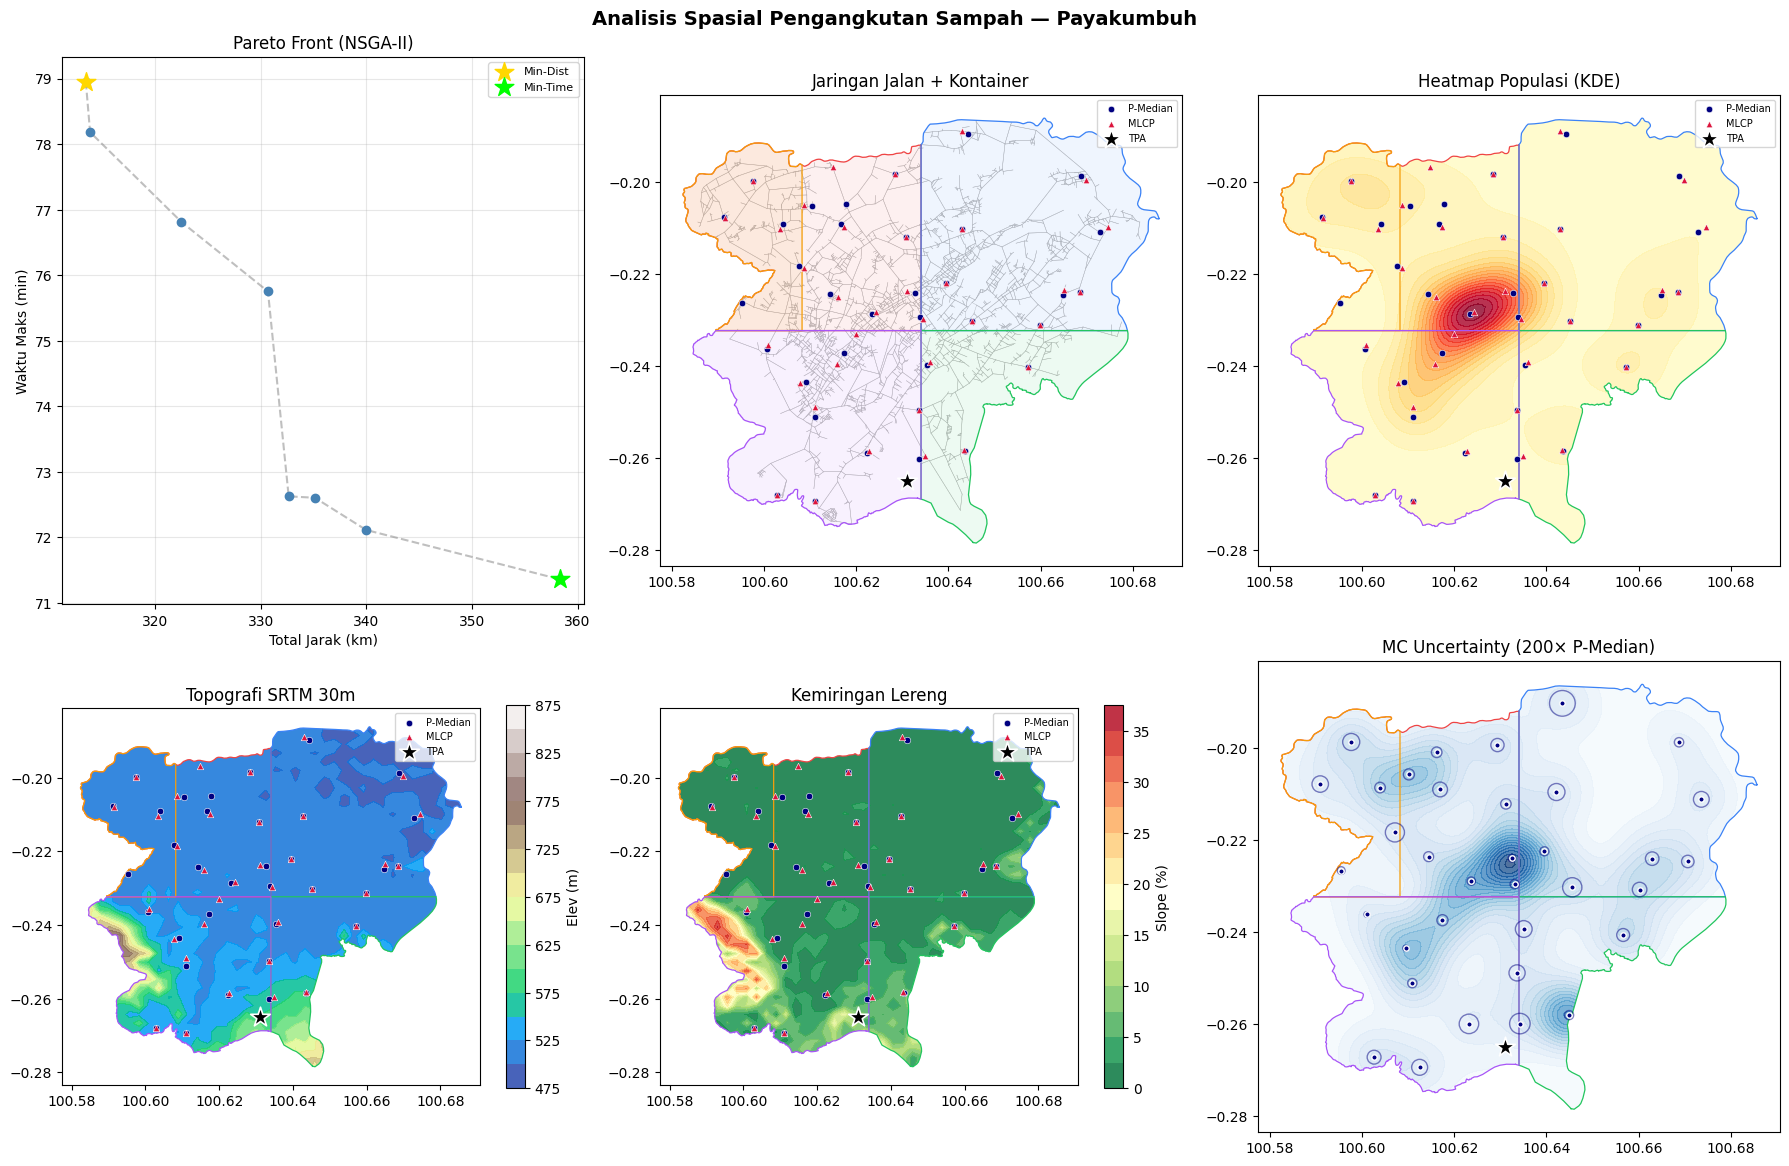

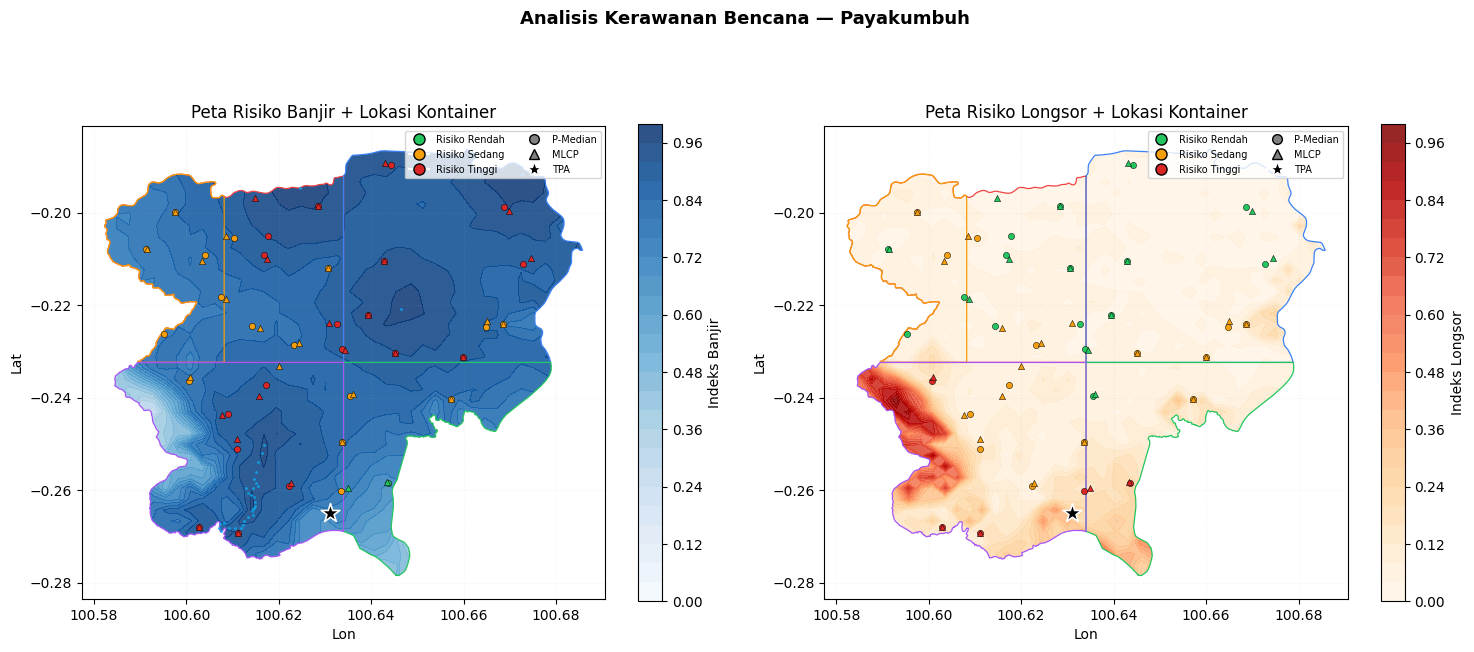

In [39]:
np.random.seed(SEED)
kc = {"Payakumbuh Barat":"#ef4444","Payakumbuh Utara":"#3b82f6","Payakumbuh Timur":"#22c55e",
      "Lamposi Tigo Nagari":"#f59e0b","Payakumbuh Selatan":"#a855f7"}
x0, y0, x1, y1 = city.bounds; pad = 0.005

def dkec(a, fa=0.08):
    for k,p in poly.items():
        for g in (p.geoms if p.geom_type=="MultiPolygon" else [p]):
            x,y = g.exterior.xy
            if fa: a.fill(x,y,color=kc[k],alpha=fa,zorder=2)
            a.plot(x,y,color=kc[k],lw=0.9,zorder=3)

def dcont(a, size=22):
    a.scatter([c["lon"] for c in C_pm],[c["lat"] for c in C_pm], c="navy", s=size, zorder=5, edgecolor="w", lw=0.4, label="P-Median")
    a.scatter([c["lon"] for c in C_ml],[c["lat"] for c in C_ml], c="crimson", marker="^", s=size, zorder=5, edgecolor="w", lw=0.4, label="MLCP")
    a.scatter(TPA[1],TPA[0], c="black", marker="*", s=220, zorder=7, edgecolor="white", lw=1.2, label="TPA")
    a.legend(fontsize=7, loc="upper right"); a.set_aspect("equal")
    a.set_xlim(x0-pad,x1+pad); a.set_ylim(y0-pad,y1+pad)

def clip_city(ax, cs):
    polys = city.geoms if hasattr(city, "geoms") else [city]
    p = PathPatch(MPath(np.array(polys[0].exterior.coords)),
                  transform=ax.transData, facecolor="none", edgecolor="none")
    ax.add_patch(p)
    try:
        cs.set_clip_path(p)                              # matplotlib ≥ 3.8
    except AttributeError:
        for coll in cs.collections: coll.set_clip_path(p)  # fallback

# ── FIGURE 1: 6-Panel utama ──────────────────────────────────────────────────
fig, ax = plt.subplots(2, 3, figsize=(18,12))
xx,yy = np.mgrid[x0:x1:100j, y0:y1:100j]

a = ax[0,0]
a.scatter(PF[:,0], PF[:,1], c="steelblue", zorder=3)
a.plot(np.sort(PF[:,0]), PF[np.argsort(PF[:,0]),1], "--", color="gray", alpha=.5)
a.scatter(PF[:,0].min(), PF[np.argmin(PF[:,0]),1], c="gold", marker="*", s=200, label="Min-Dist", zorder=4)
a.scatter(PF[np.argmin(PF[:,1]),0], PF[:,1].min(), c="lime", marker="*", s=200, label="Min-Time", zorder=4)
a.set(xlabel="Total Jarak (km)", ylabel="Waktu Maks (min)", title="Pareto Front (NSGA-II)")
a.legend(fontsize=8); a.grid(alpha=.3)

a = ax[0,1]
for u,v,_ in G.edges(keys=True):
    a.plot([G.nodes[u]["x"],G.nodes[v]["x"]],[G.nodes[u]["y"],G.nodes[v]["y"]], color="#bbb", lw=0.3, zorder=1)
dkec(a); dcont(a); a.set_title("Jaringan Jalan + Kontainer")

a = ax[0,2]
samp = np.random.RandomState(SEED).choice(len(bx), min(1500,len(bx)), replace=False)
kde = gaussian_kde(np.vstack([bx[samp], by[samp]]))
cs = a.contourf(xx, yy, kde(np.vstack([xx.ravel(),yy.ravel()])).reshape(xx.shape), levels=20, cmap="YlOrRd", alpha=0.8, zorder=1)
clip_city(a, cs); dkec(a,fa=0); dcont(a); a.set_title("Heatmap Populasi (KDE)")

a = ax[1,0]
cs = a.contourf(EX,EY,EZ, levels=15, cmap="terrain", alpha=0.85, zorder=1)
clip_city(a, cs); plt.colorbar(cs, ax=a, shrink=0.7, label="Elev (m)")
dkec(a,fa=0); dcont(a); a.set_title("Topografi SRTM 30m")

a = ax[1,1]
cs = a.contourf(EX,EY,slope, levels=15, cmap="RdYlGn_r", alpha=0.85, zorder=1)
clip_city(a, cs); plt.colorbar(cs, ax=a, shrink=0.7, label="Slope (%)")
dkec(a,fa=0); dcont(a); a.set_title("Kemiringan Lereng")

a = ax[1,2]
kde2 = gaussian_kde(np.vstack([all_pm[:,1], all_pm[:,0]]))
cs = a.contourf(xx,yy, kde2(np.vstack([xx.ravel(),yy.ravel()])).reshape(xx.shape), levels=20, cmap="Blues", alpha=0.7, zorder=1)
clip_city(a, cs)
for s in stats_pm:
    a.add_patch(plt.Circle((s['lon'],s['lat']), s['std_km']/111, color='navy', fill=False, lw=1, alpha=0.5, zorder=4))
    a.scatter(s['lon'],s['lat'], c='navy', s=15, edgecolor='w', zorder=5)
a.scatter(TPA[1],TPA[0],c="black",marker="*",s=220,zorder=6,edgecolor="w",lw=1.2)
dkec(a,fa=0); a.set_title(f"MC Uncertainty ({N_RUNS}× P-Median)")
a.set_aspect("equal"); a.set_xlim(x0-pad,x1+pad); a.set_ylim(y0-pad,y1+pad)

plt.suptitle("Analisis Spasial Pengangkutan Sampah — Payakumbuh", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("analisis.png", dpi=200, bbox_inches="tight"); plt.show()

# ── FIGURE 2: Hazard 2-Panel ─────────────────────────────────────────────────
def color_of(v, p33, p66): return "#22c55e" if v<p33 else "#f59e0b" if v<p66 else "#dc2626"

legend_h = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#22c55e', markersize=8, markeredgecolor='black', label='Risiko Rendah'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#f59e0b', markersize=8, markeredgecolor='black', label='Risiko Sedang'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#dc2626', markersize=8, markeredgecolor='black', label='Risiko Tinggi'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=7, markeredgecolor='black', label='P-Median'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='gray', markersize=7, markeredgecolor='black', label='MLCP'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='black', markersize=11, label='TPA')]

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
for i, (risk, p33, p66, fHaz, title, cmap) in enumerate([
    (flood_risk, fl_p33, fl_p66, fFlood, "Banjir", "Blues"),
    (landslide_risk, ls_p33, ls_p66, fLand, "Longsor", "OrRd"),
]):
    a = ax[i]
    cs = a.contourf(EX, EY, risk, levels=25, cmap=cmap, alpha=0.85, zorder=1)
    clip_city(a, cs); plt.colorbar(cs, ax=a, shrink=0.75, label=f"Indeks {title}")
    if i==0 and water_pts:
        wp = np.array(water_pts); inside = (wp[:,0]>=y0)&(wp[:,0]<=y1)&(wp[:,1]>=x0)&(wp[:,1]<=x1)
        a.scatter(wp[inside,1], wp[inside,0], c="#0ea5e9", s=1.5, alpha=0.7, zorder=4)
    dkec(a, fa=0)
    for src, marker in [(C_pm,"o"), (C_ml,"^")]:
        for c in src:
            v = float(fHaz((c["lat"], c["lon"])))
            a.scatter(c["lon"], c["lat"], c=color_of(v,p33,p66), marker=marker, s=20,
                      edgecolor="black", linewidth=0.35, zorder=6)
    a.scatter(TPA[1], TPA[0], c="black", marker="*", s=200, zorder=7, edgecolor="white", lw=1.2)
    a.set(title=f"Peta Risiko {title} + Lokasi Kontainer", xlabel="Lon", ylabel="Lat")
    a.set_xlim(x0-pad,x1+pad); a.set_ylim(y0-pad,y1+pad); a.set_aspect("equal")
    a.grid(alpha=0.15, linestyle=":"); a.legend(handles=legend_h, loc="upper right", fontsize=7, ncol=2)

plt.suptitle("Analisis Kerawanan Bencana — Payakumbuh", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("hazard.png", dpi=200, bbox_inches="tight"); plt.show()

NSGA-II P-Median...
NSGA-II MLCP...


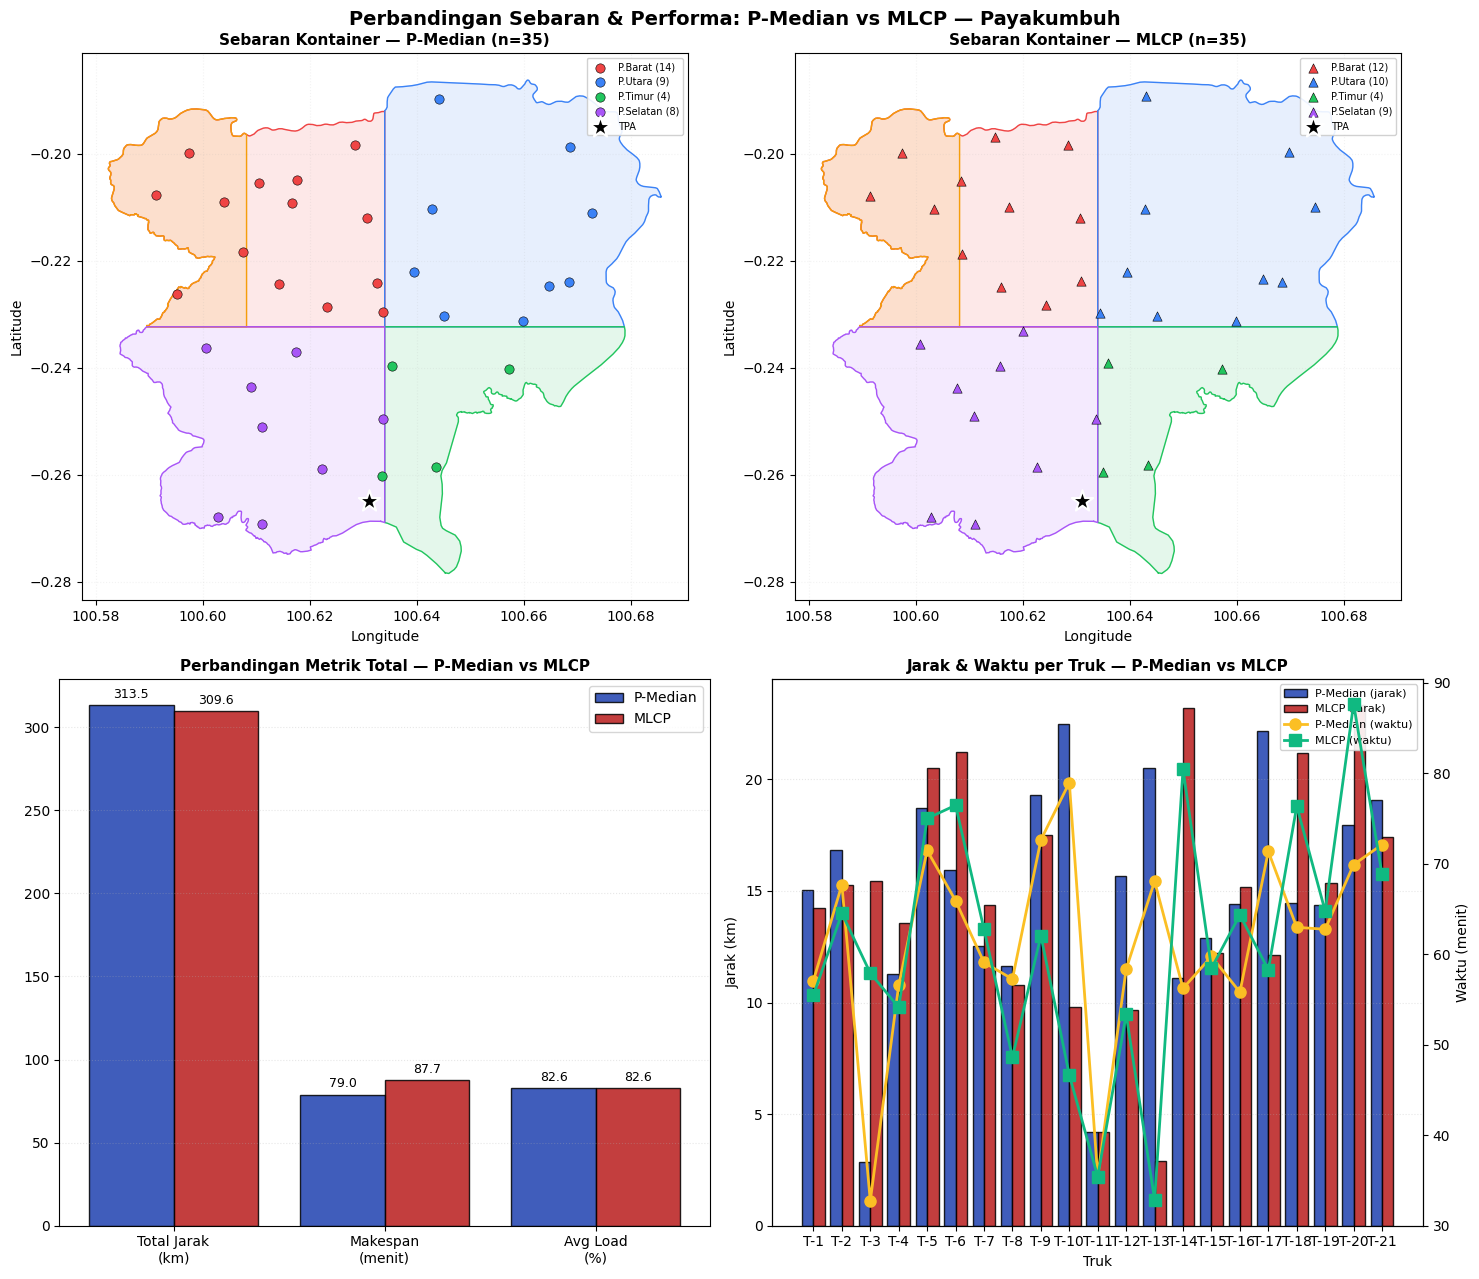


══ PERBANDINGAN P-Median vs MLCP ══
          metric  P-Median   MLCP  Δ (MLCP-PM)
Total Jarak (km)    313.46 309.55        -3.91
  Makespan (min)     79.00  87.70         8.70
    Avg Load (%)     82.60  82.60        -0.00
    Truk dipakai     21.00  21.00         0.00

Saved: comparison.png, output/10_comparison.csv


In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Scatter Sebaran + Perbandingan P-Median vs MLCP
# ══════════════════════════════════════════════════════════════════════════════
random.seed(SEED); np.random.seed(SEED)

def run_nsga(containers):
    """Run NSGA-II untuk container set, return best solution + truck stats."""
    n = len(containers); nodes = [DEPOT] + [c["node"] for c in containers]
    Mc = np.zeros((n+1, n+1))
    for i, u in enumerate(nodes):
        L = nx.single_source_dijkstra_path_length(G, u, weight="length")
        for j, v in enumerate(nodes): Mc[i,j] = L.get(v, 0)/1000
    fl = np.array([0] + [c["fill"] for c in containers])

    def split_f(perm):
        rs, r, ld = [], [], 0
        for i in perm:
            if ld+fl[i+1]>CAP: rs.append(r); r,ld=[],0
            r.append(i+1); ld += fl[i+1]
        return rs+([r] if r else [])
    def cost_f(r): return Mc[0,r[0]] + sum(Mc[r[k],r[k+1]] for k in range(len(r)-1)) + Mc[r[-1],0]
    def fobj_f(ind):
        rs = split_f(ind); km = sum(cost_f(r) for r in rs)
        tm = max(cost_f(r)/SPEED*60 + len(r)*T_LOAD + T_UNLOAD for r in rs) if rs else 999
        return km, tm

    tb_l = base.Toolbox()
    tb_l.register("ind", tools.initIterate, creator.Ind, lambda: random.sample(range(n), n))
    tb_l.register("pop", tools.initRepeat, list, tb_l.ind)
    tb_l.register("evaluate", fobj_f); tb_l.register("mate", tools.cxOrdered)
    tb_l.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
    tb_l.register("select", tools.selNSGA2)

    random.seed(SEED); np.random.seed(SEED)
    hof_l = tools.ParetoFront()
    algorithms.eaMuPlusLambda(tb_l.pop(n=60), tb_l, mu=60, lambda_=60,
                              cxpb=0.7, mutpb=0.3, ngen=80, halloffame=hof_l, verbose=False)
    PF_l = np.array([ind.fitness.values for ind in hof_l])
    best = hof_l[int(np.argmin(PF_l[:,0]))]
    routes = split_f(best)
    trucks = [{"truck":i+1, "distance_km":cost_f(r),
               "time_min":cost_f(r)/SPEED*60 + len(r)*T_LOAD + T_UNLOAD,
               "n_cont":len(r), "load_kg":sum(containers[j-1]["fill"] for j in r)}
              for i,r in enumerate(routes) if r]
    return {"PF":PF_l, "trucks":trucks,
            "total_km":sum(t["distance_km"] for t in trucks),
            "makespan":max(t["time_min"] for t in trucks)}

print("NSGA-II P-Median..."); res_pm = run_nsga(C_pm)
print("NSGA-II MLCP..."); res_ml = run_nsga(C_ml)

# ── Visualisasi 2×2 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(2, 2, figsize=(15, 13))

# Panel A & B: Scatter sebaran berdasarkan kecamatan
def draw_scatter(a, C_list, marker, title):
    for k, p in poly.items():
        for g in (p.geoms if p.geom_type=="MultiPolygon" else [p]):
            xs, ys = g.exterior.xy
            a.fill(xs, ys, color=kc[k], alpha=0.12, zorder=1)
            a.plot(xs, ys, color=kc[k], lw=1.0, zorder=2)
    for k, col in kc.items():
        grp = [c for c in C_list if c["kec"]==k]
        if grp:
            a.scatter([c["lon"] for c in grp], [c["lat"] for c in grp],
                      c=col, marker=marker, s=45, edgecolor="black", lw=0.4,
                      zorder=4, label=f"{k.replace('Payakumbuh ','P.')} ({len(grp)})")
    a.scatter(TPA[1], TPA[0], c="black", marker="*", s=260, edgecolor="white",
              lw=1.5, zorder=5, label="TPA")
    a.set_title(title, fontweight="bold", fontsize=11)
    a.set_xlabel("Longitude"); a.set_ylabel("Latitude"); a.set_aspect("equal")
    a.set_xlim(x0-pad, x1+pad); a.set_ylim(y0-pad, y1+pad)
    a.legend(fontsize=7, loc="upper right", framealpha=0.9); a.grid(alpha=0.15, linestyle=":")

draw_scatter(ax[0,0], C_pm, "o", f"Sebaran Kontainer — P-Median (n={len(C_pm)})")
draw_scatter(ax[0,1], C_ml, "^", f"Sebaran Kontainer — MLCP (n={len(C_ml)})")

# Panel C: Bar comparison total metrics
a = ax[1, 0]
metrics = ["Total Jarak\n(km)", "Makespan\n(menit)", "Avg Load\n(%)"]
pm_v = [res_pm["total_km"], res_pm["makespan"], np.mean([t["load_kg"]/CAP*100 for t in res_pm["trucks"]])]
ml_v = [res_ml["total_km"], res_ml["makespan"], np.mean([t["load_kg"]/CAP*100 for t in res_ml["trucks"]])]
xp = np.arange(len(metrics))
b1 = a.bar(xp-0.2, pm_v, 0.4, label="P-Median", color="#1e40af", alpha=0.85, edgecolor="black")
b2 = a.bar(xp+0.2, ml_v, 0.4, label="MLCP",     color="#b91c1c", alpha=0.85, edgecolor="black")
a.bar_label(b1, fmt="%.1f", fontsize=9, padding=3)
a.bar_label(b2, fmt="%.1f", fontsize=9, padding=3)
a.set_xticks(xp); a.set_xticklabels(metrics, fontsize=10)
a.set_title("Perbandingan Metrik Total — P-Median vs MLCP", fontweight="bold", fontsize=11)
a.legend(fontsize=10, loc="upper right"); a.grid(alpha=0.3, axis="y", linestyle=":")

# Panel D: Per-truck distance + time (dual axis)
a = ax[1, 1]
n_max = max(len(res_pm["trucks"]), len(res_ml["trucks"]))
tids = np.arange(1, n_max+1)
pm_km = [t["distance_km"] for t in res_pm["trucks"]] + [0]*(n_max-len(res_pm["trucks"]))
ml_km = [t["distance_km"] for t in res_ml["trucks"]] + [0]*(n_max-len(res_ml["trucks"]))
pm_tm = [t["time_min"] for t in res_pm["trucks"]] + [0]*(n_max-len(res_pm["trucks"]))
ml_tm = [t["time_min"] for t in res_ml["trucks"]] + [0]*(n_max-len(res_ml["trucks"]))

a.bar(tids-0.2, pm_km, 0.4, color="#1e40af", alpha=0.85, label="P-Median (jarak)", edgecolor="black")
a.bar(tids+0.2, ml_km, 0.4, color="#b91c1c", alpha=0.85, label="MLCP (jarak)",     edgecolor="black")
a.set_xticks(tids); a.set_xticklabels([f"T-{i}" for i in tids])
a.set_xlabel("Truk"); a.set_ylabel("Jarak (km)", color="black")
a.set_title("Jarak & Waktu per Truk — P-Median vs MLCP", fontweight="bold", fontsize=11)
a.grid(alpha=0.3, axis="y", linestyle=":")

a2 = a.twinx()
a2.plot(tids, pm_tm, "o-", color="#fbbf24", lw=2, markersize=8, label="P-Median (waktu)")
a2.plot(tids, ml_tm, "s-", color="#10b981", lw=2, markersize=8, label="MLCP (waktu)")
a2.set_ylabel("Waktu (menit)", color="black")

lines1, labels1 = a.get_legend_handles_labels()
lines2, labels2 = a2.get_legend_handles_labels()
a.legend(lines1+lines2, labels1+labels2, fontsize=8, loc="upper right", framealpha=0.9)

plt.suptitle("Perbandingan Sebaran & Performa: P-Median vs MLCP — Payakumbuh",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison.png", dpi=200, bbox_inches="tight"); plt.show()

# ── Tabel ringkasan ──────────────────────────────────────────────────────────
df_compare = pd.DataFrame([
    {"metric":"Total Jarak (km)",  "P-Median":round(res_pm["total_km"],2),  "MLCP":round(res_ml["total_km"],2),
     "Δ (MLCP-PM)":round(res_ml["total_km"]-res_pm["total_km"],2)},
    {"metric":"Makespan (min)",     "P-Median":round(res_pm["makespan"],1),  "MLCP":round(res_ml["makespan"],1),
     "Δ (MLCP-PM)":round(res_ml["makespan"]-res_pm["makespan"],1)},
    {"metric":"Avg Load (%)",       "P-Median":round(np.mean([t["load_kg"]/CAP*100 for t in res_pm["trucks"]]),1),
     "MLCP":round(np.mean([t["load_kg"]/CAP*100 for t in res_ml["trucks"]]),1),
     "Δ (MLCP-PM)":round(np.mean([t["load_kg"]/CAP*100 for t in res_ml["trucks"]]) -
                          np.mean([t["load_kg"]/CAP*100 for t in res_pm["trucks"]]),1)},
    {"metric":"Truk dipakai",       "P-Median":len(res_pm["trucks"]), "MLCP":len(res_ml["trucks"]),
     "Δ (MLCP-PM)":len(res_ml["trucks"])-len(res_pm["trucks"])},
])
print("\n══ PERBANDINGAN P-Median vs MLCP ══"); print(df_compare.to_string(index=False))

df_compare.to_csv("output/10_comparison.csv", index=False)
if os.path.exists("comparison.png"): shutil.copy("comparison.png", "output/comparison.png")
print("\nSaved: comparison.png, output/10_comparison.csv")